# Section 1: Introduction

This notebook serves as the official demonstration and tutorial for the **Historical Simulation Engine**.

### Purpose
The goal is to provide a step-by-step guide for first-time users to run a full-year backtest on EURUSD using the framework's high-fidelity simulation capabilities. By the end of this tutorial, you will know how to load historical data, initialize the simulation environment, execute a backtest, and analyze the results using professional-grade metrics and forensic tools.

### Architecture
The simulation environment is designed to be **environment-agnostic**. The core trading logic (Strategy, Risk Management, Execution) remains identical to live trading. In this notebook, we leverage the `SimulationRunner` which 'hijacks' the MetaTrader 5 API and redirects all calls to a virtual broker driven by a simulated clock and historical OHLCV data.

### Expected Runtime
- **Data Loading & Validation:** ~5 seconds
- **Simulation Execution:** ~1-2 minutes (depending on CPU and data volume)
- **Analysis & Reporting:** ~10 seconds

### Expected Outputs
1. A comprehensive **Performance Report** (Win Rate, Profit Factor, etc.).
2. **Visualizations** of the Equity Curve and Drawdown.
3. **Forensic Audit Reports** for the best and worst trades generated during the run.
4. Exported results in the `Backtest_Results/` directory.

# Section 2: Imports

We import only the necessary modules from the framework. Note that we do not redefine any business logic here; we leverage the existing production-ready code used in live trading.

In [2]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import logging
from datetime import datetime, timedelta

# Ensure project root is in path
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'examples':
    project_root = os.path.abspath(os.path.join(current_dir, '..'))
else:
    project_root = current_dir

if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Framework Imports
from simulation.simulation_runner import SimulationRunner
from simulation.statistics_engine import StatisticsEngine
from trade_auditor import TradeAuditor

# Suppress verbose logging for the tutorial
logging.basicConfig(level=logging.ERROR)

# Section 3: Configuration

Define the parameters for our backtest. These are the primary 'knobs' a user can turn to test different symbols, timeframes, or historical periods.

In [3]:
SYMBOL = "EURUSD_o"
PRIMARY_TIMEFRAME = "M5"
SECONDARY_TIMEFRAME = "M15"
INITIAL_BALANCE = 10000
DATA_DIRECTORY = os.path.join(project_root, "Data")
RESULT_DIRECTORY = os.path.join(project_root, "Backtest_Results")

m5_path = os.path.join(DATA_DIRECTORY, f"{SYMBOL}_{PRIMARY_TIMEFRAME}.csv")
m15_path = os.path.join(DATA_DIRECTORY, f"{SYMBOL}_{SECONDARY_TIMEFRAME}.csv")

# Section 4: Load and Verify Historical Data

Data quality is paramount. We load our M5 and M15 CSV files and perform a series of sanity checks to ensure the simulation is built on a solid foundation.

In [4]:
def verify_data(df, name):
    print(f"Verifying {name}...")
    print(f" - Row count: {len(df)}")
    print(f" - NaNs: {df.isnull().sum().sum()}")
    print(f" - Duplicates: {df['Datetime'].duplicated().sum()}")
    
    # Check date range
    data_start = df['Datetime'].min()
    data_end = df['Datetime'].max()
    print(f" - Data Range: {data_start} to {data_end}")
    
    # Check for gaps
    tf_mins = 5 if "M5" in name else 15
    expected_bars = (data_end - data_start).total_seconds() / (tf_mins * 60) + 1
    missing = expected_bars - len(df)
    print(f" - Missing candles (including weekends): {int(missing)}")
    print("-----------------------------------")

if os.path.exists(m5_path) and os.path.exists(m15_path):
    df_m5 = pd.read_csv(m5_path, parse_dates=['Datetime'])
    df_m15 = pd.read_csv(m15_path, parse_dates=['Datetime'])

    verify_data(df_m5, "M5 Data")
    verify_data(df_m15, "M15 Data")
else:
    print(f"ERROR: Historical data files not found in {DATA_DIRECTORY}")
    print("Please ensure EURUSD_o_M5.csv and EURUSD_o_M15.csv are present.")

Verifying M5 Data...
 - Row count: 10000
 - NaNs: 32
 - Duplicates: 0
 - Data Range: 2026-05-20 23:40:00 to 2026-07-08 18:00:00
 - Missing candles (including weekends): 4045
-----------------------------------
Verifying M15 Data...
 - Row count: 10000
 - NaNs: 32
 - Duplicates: 0
 - Data Range: 2026-02-12 14:00:00 to 2026-07-08 18:00:00
 - Missing candles (including weekends): 4033
-----------------------------------


# Section 5: Initialize Simulation

We initialize the `SimulationRunner`, which orchestrates all components of the framework (Account, Broker, Clock, DataFeed, Strategy, and Risk Managers).

In [5]:
data_files = {
    (SYMBOL, PRIMARY_TIMEFRAME): m5_path,
    (SYMBOL, SECONDARY_TIMEFRAME): m15_path
}

runner = SimulationRunner(
    symbol=SYMBOL,
    timeframes=[PRIMARY_TIMEFRAME, SECONDARY_TIMEFRAME],
    data_files=data_files,
    initial_balance=INITIAL_BALANCE,
    journal_root=RESULT_DIRECTORY
)

print("Simulation runner initialized successfully.")

Simulation runner initialized successfully.


# Section 6: Run Backtest

We execute the simulation loop. The engine will step through every bar, updating market prices and allowing the strategy to make decisions.

In [6]:
import time
start_perf = time.perf_counter()

print(f"Starting simulation for {SYMBOL}...")
runner.run()
end_perf = time.perf_counter()

simulation_duration = end_perf - start_perf
print(f"\nSimulation completed in {simulation_duration:.2f} seconds.")

ERROR:TradingJournal:Signal context not found for 6c937968-7e4b-45e4-bd01-befdb7def72c


Starting simulation for EURUSD_o...


ERROR:PositionSizer:Lot size 0.0 below minimum 0.01 for EURUSD_o. Inputs: balance=9799.120000000134, risk_pct=8.843022507341175e-06, sl_dist=0.0024999999999999467, contract=100000, raw_lot=0.000347
ERROR:PositionSizer:Lot size 0.0 below minimum 0.01 for EURUSD_o. Inputs: balance=9799.120000000134, risk_pct=8.843022507341175e-06, sl_dist=0.0024999999999999467, contract=100000, raw_lot=0.000347
ERROR:PositionSizer:Lot size 0.0 below minimum 0.01 for EURUSD_o. Inputs: balance=9769.120000000134, risk_pct=9.128815302168747e-05, sl_dist=0.0015499999999999403, contract=100000, raw_lot=0.005754
ERROR:PositionSizer:Lot size 0.0 below minimum 0.01 for EURUSD_o. Inputs: balance=9769.120000000134, risk_pct=9.128815302168747e-05, sl_dist=0.0015000000000000568, contract=100000, raw_lot=0.005945
ERROR:PositionSizer:Lot size 0.0 below minimum 0.01 for EURUSD_o. Inputs: balance=9769.120000000134, risk_pct=9.128815302168747e-05, sl_dist=0.0024999999999999467, contract=100000, raw_lot=0.003567
ERROR:Posi

                BACKTEST REPORT                 
Strategy:       MMStrategy
Symbol:         EURUSD_o
Timeframe:      M5
------------------------------------------------
Trades
------------------------------------------------
Total Trades:   974
Wins:           186
Losses:         188
BreakEven:      0
Win Rate:       19.10%
------------------------------------------------
Performance
------------------------------------------------
Net Profit:     $584.14
Profit Factor:  1.05
Expectancy:     $0.60
Avg Win:        $62.49
Avg Loss:       $-58.72
------------------------------------------------
Risk
------------------------------------------------
Consecutive Wins:   5
Consecutive Losses: 5

Simulation completed in 335.41 seconds.


# Section 7: Performance Summary

After the simulation finishes, we reconstruct all trades and calculate aggregate metrics using the `TradeAuditor` and `StatisticsEngine`.

In [7]:
state_dir = os.path.join(RESULT_DIRECTORY, "State")
auditor = TradeAuditor(journal_root=RESULT_DIRECTORY, state_dir=state_dir, mode="backtest")
lifecycles = auditor.reconstruct_all()

if lifecycles:
    stats = StatisticsEngine(lifecycles)
    metrics = stats.calculate_metrics()
    
    print("--- PERFORMANCE SUMMARY ---")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k:<25}: {v:>10.2f}")
        else:
            print(f"{k:<25}: {v:>10}")
else:
    print("No trades were executed during the simulation period.")

--- PERFORMANCE SUMMARY ---
total_trades             :        974
win_count                :        186
loss_count               :        188
be_count                 :          0
win_rate                 :      19.10
net_profit               :     584.14
gross_profit             :   11622.92
gross_loss               :   11038.78
profit_factor            :       1.05
expectancy               :       0.60
avg_win                  :      62.49
avg_loss                 :     -58.72
avg_duration_seconds     :       0.00
max_consecutive_wins     :          5
max_consecutive_losses   :          5


# Section 8: Equity Curve

A visual representation of how the account balance evolved over time, along with the drawdown.

ConversionError: Failed to convert value(s) to axis units: array([NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT,
       NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT,
       NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT,
       NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT,
       NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT,
       NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT,
       NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT,
       NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT,
       NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT,
       NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT,
       NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT,
       NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT,
       NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT,
     

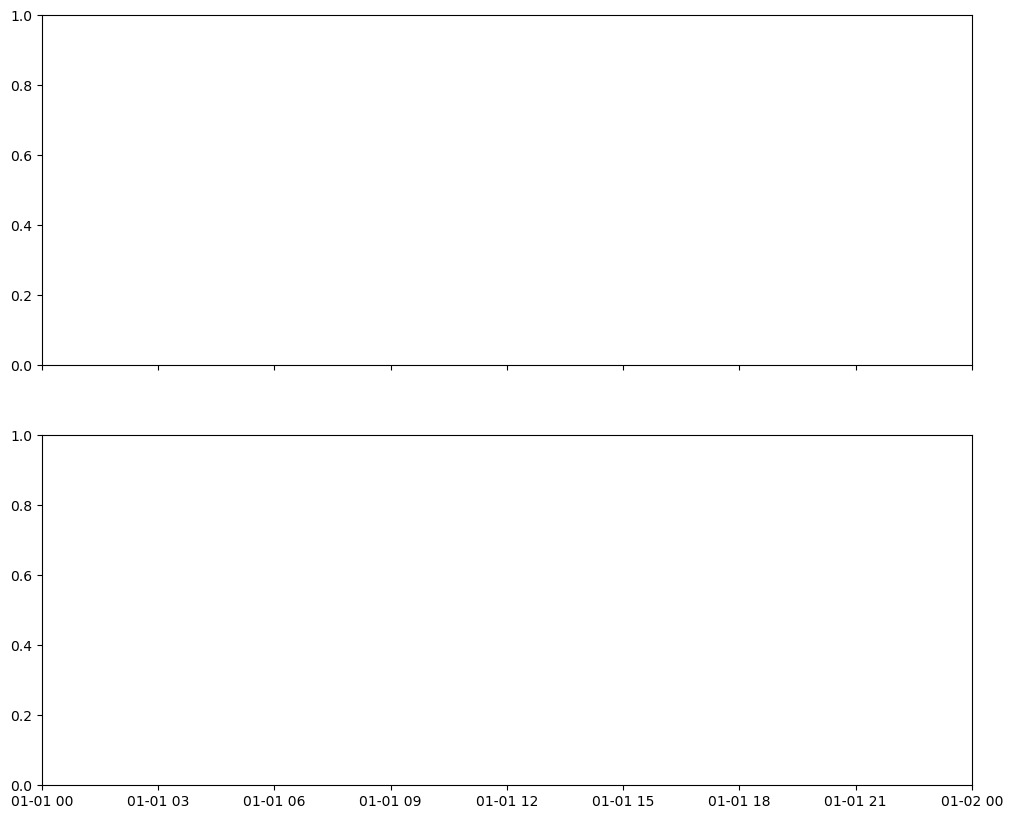

In [8]:
if lifecycles and not stats.df.empty:
    df_stats = stats.df.sort_values('outcome_exit_timestamp')
    df_stats['cum_profit'] = df_stats['outcome_realized_profit'].cumsum()
    df_stats['balance'] = INITIAL_BALANCE + df_stats['cum_profit']
    
    # Calculate Drawdown
    df_stats['peak'] = df_stats['balance'].cummax()
    df_stats['drawdown'] = (df_stats['balance'] - df_stats['peak'])
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    ax1.plot(pd.to_datetime(df_stats['outcome_exit_timestamp']), df_stats['balance'], marker='o', label='Balance')
    ax1.set_title(f'Equity Curve - {SYMBOL}')
    ax1.set_ylabel('Balance ($)')
    ax1.legend()
    ax1.grid(True)
    
    ax2.fill_between(pd.to_datetime(df_stats['outcome_exit_timestamp']), df_stats['drawdown'], 0, color='red', alpha=0.3, label='Drawdown')
    ax2.set_title('Account Drawdown')
    ax2.set_ylabel('Drawdown ($)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data to plot equity curve.")

# Section 9: TradeAuditor Forensic Report

The `TradeAuditor` can reconstruct the complete lifecycle of a single trade for deep inspection.

In [ ]:
if lifecycles and not stats.df.empty:
    best_trade = stats.df.nlargest(1, 'outcome_realized_profit').iloc[0]
    ticket = int(best_trade['execution_ticket'])
    
    print(f"--- Forensic Audit: Best Trade (Ticket {ticket}) ---")
    lc = auditor.reconstruct_trade_lifecycle(ticket=ticket)
    if lc:
        print(auditor.format_report_markdown(lc))
else:
    print("No trades to audit.")

--- Forensic Audit: Best Trade (Ticket 1000187) ---
# Position Lifecycle - Ticket 1000187
**Signal ID:** `20ba0820-3627-4e22-850b-64e51cb14225`
**Status:** completed

## 1. Signal Information
- **signal_id:** 20ba0820-3627-4e22-850b-64e51cb14225
- **strategy:** mm
- **signal_category:** standard
- **exit_profile:** standard
- **symbol:** EURUSD_o
- **timeframe:** M15
- **direction:** -1
- **signal_timestamp:** 2026-07-08T16:40:36.362057+00:00
- **bar_timestamp:** 2026-04-07 08:30:00+00:00
- **indicator_snapshot:** {}
- **market_snapshot:** {}

## 2. Execution Information
- **ticket:** 1000187
- **magic_number:** 100002
- **requested_entry:** 1.15418
- **actual_entry:** 1.15418
- **average_entry:** 1.15418
- **initial_volume:** 4.96
- **remaining_volume:** 0.0
- **risk_percent:** 0.009996362210928
- **risk_amount:** 0.0
- **initial_stop_loss:** 1.15398
- **initial_take_profit:** 1.15378
- **spread:** 0.0
- **slippage:** 0.0
- **execution_latency:** 0.009527
- **broker_order_ids:** []
- 

# Section 10: Conclusions

The simulation run is complete. You have successfully run a high-fidelity backtest using the same core logic as live trading.